In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
from uncertainties import ufloat
from uncertainties import unumpy
from scipy import odr
import pandas as pd

# Schritt 1

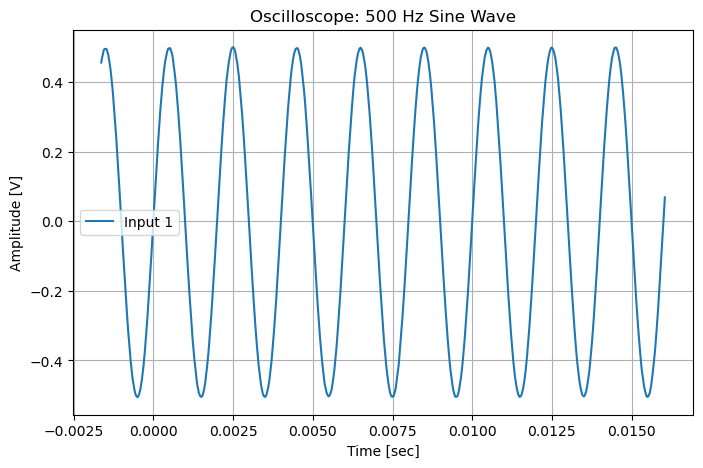

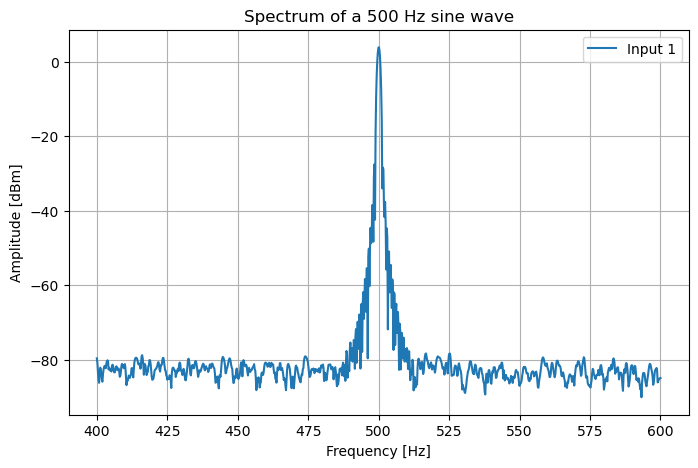

In [2]:

#Amplitude
V_peak = 999.1 #V
V_peak_std = 1.138 #Vm 
#Frequenz 
f_peak = 500.4 #Hz
f_std = 19.35 #mHz
#Frequenz



data = pd.read_csv(
    "Messung_OS_teil1.csv",
    comment="%",
    header=None,
    names=["Amplitude", "Time"],
    skipinitialspace=True
)

data.head()

plt.figure(figsize=(8, 5))
plt.plot(data["Amplitude"], data["Time"], label="Input 1")

plt.xlabel("Time [sec]")
plt.ylabel("Amplitude [V]")
plt.title("Oscilloscope: 500 Hz Sine Wave")
plt.grid(True)
plt.legend()
plt.savefig('Plots/OS_sin.png')
plt.show()


data = pd.read_csv(
    "Messung_SA_teil1.csv",
    comment="%",
    header=None,
    names=["PSD", "Frequenz" ],
    skipinitialspace=True
)

data.head()

plt.figure(figsize=(8, 5))
plt.plot(data["PSD"], data["Frequenz"], label="Input 1")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude [dBm]")
plt.title("Spectrum of a 500 Hz sine wave")
plt.grid(True)
plt.legend()
plt.savefig('Plots/SA_sin.png')
plt.show()

# Schritt 2

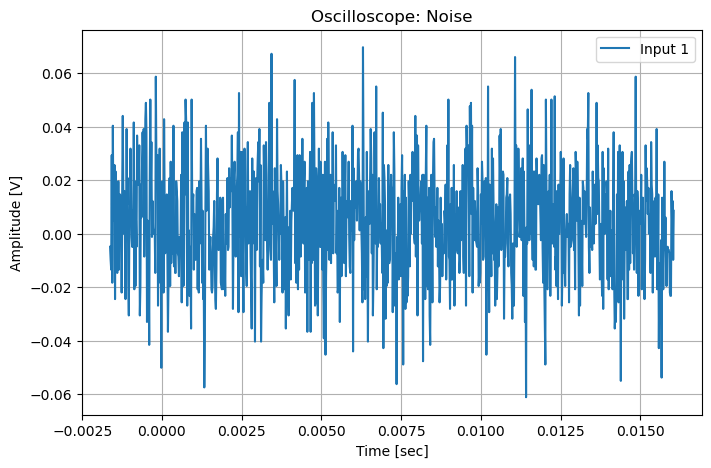

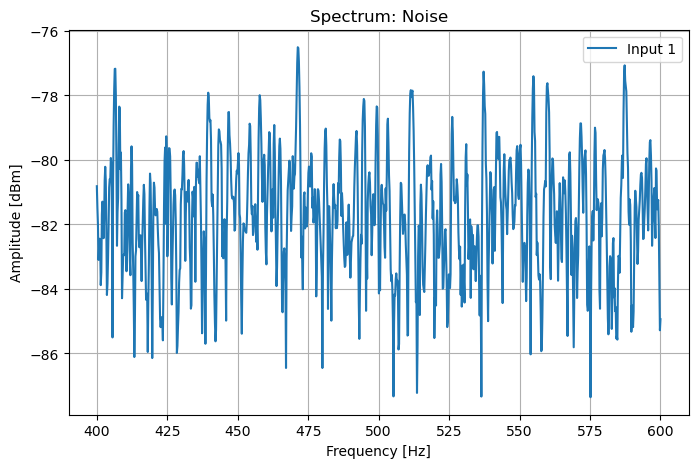

In [3]:

#Amplitude
V_peak = 51.3 #mV
V_peak_st = 30.83 #mV

# Frequency settings
freq_min = 400       # in Hz (z.B. 0)
freq_max = 600       # in Hz (z.B. 10000)

#sacle: "linear"


# Spectrum Analyzer settings
RBW = 977.5             # Resolution Bandwidth in Hz (z.B. 100)

frame_averages = 10  # z.B. 10

data = pd.read_csv(
    "Messung_OS_teil2.csv",
    comment="%",
    header=None,
    names=["Amplitude", "Time"],
    skipinitialspace=True
)

data.head()

plt.figure(figsize=(8, 5))
plt.plot(data["Amplitude"], data["Time"], label="Input 1")

plt.xlabel("Time [sec]")
plt.ylabel("Amplitude [V]")
plt.title("Oscilloscope: Noise")
plt.grid(True)
plt.legend()
plt.show()

data = pd.read_csv(
    "Messung_SA_teil2.csv",
    comment="%",
    header=None,
    names=["Frequency", "Input1_dBm"],
    skipinitialspace=True
)

data.head()

plt.figure(figsize=(8, 5))
plt.plot(data["Frequency"], data["Input1_dBm"], label="Input 1")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude [dBm]")
plt.title("Spectrum: Noise")
plt.grid(True)
plt.legend()
plt.show()

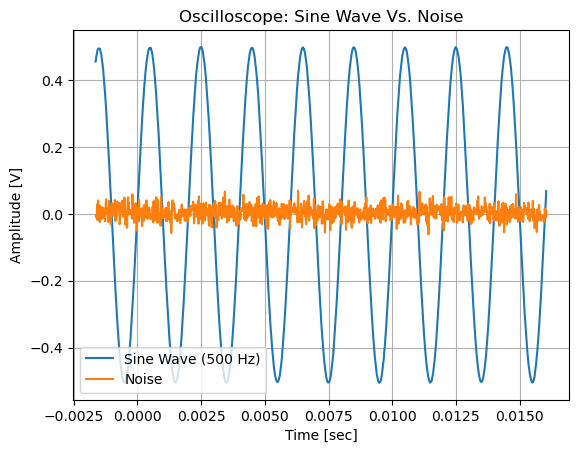

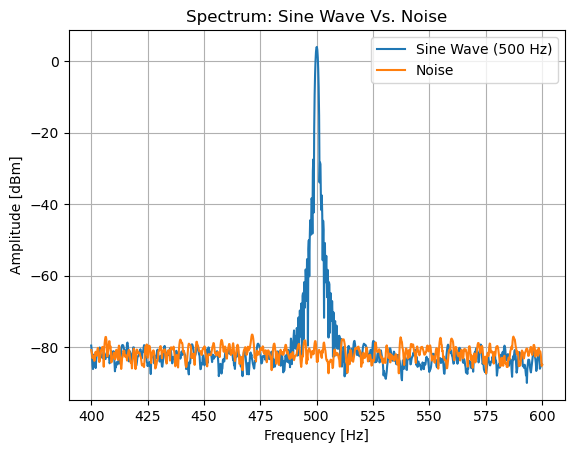

In [4]:
data1 = pd.read_csv(
    "Messung_OS_teil1.csv",
    comment="%",
    header=None,
    names=["Time_sin", "Amplitude_sin"],
    skipinitialspace=True
)

data2 = pd.read_csv(
    "Messung_OS_teil2.csv",
    comment="%",
    header=None,
    names=["Time_noise", "Amplitude_noise"],
    skipinitialspace=True
)

plt.plot(data1["Time_sin"], data1["Amplitude_sin"], label="Sine Wave (500 Hz)")
plt.plot(data2["Time_noise"], data2["Amplitude_noise"], label="Noise")
plt.xlabel("Time [sec]")
plt.ylabel("Amplitude [V]")
plt.title("Oscilloscope: Sine Wave Vs. Noise")
plt.grid(True)
plt.legend()
plt.savefig('Plots/OS_noise_sin.png')
plt.show()


data1 = pd.read_csv(
    "Messung_SA_teil1.csv",
    comment="%",
    header=None,
    names=["Frequency_sin", "Amplitude_sin"],
    skipinitialspace=True
)
data2 = pd.read_csv(
    "Messung_SA_teil2.csv",
    comment="%",
    header=None,
    names=["Frequency_noise", "Amplitude_noise"],
    skipinitialspace=True
)


data.head()

plt.plot(data1["Frequency_sin"], data1["Amplitude_sin"], label="Sine Wave (500 Hz)")
plt.plot(data2["Frequency_noise"], data2["Amplitude_noise"], label= "Noise")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude [dBm]")
plt.title("Spectrum: Sine Wave Vs. Noise")
plt.grid(True)
plt.legend()
plt.savefig('Plots/SA_noise_sin.png')
plt.show()

# Schritt 3

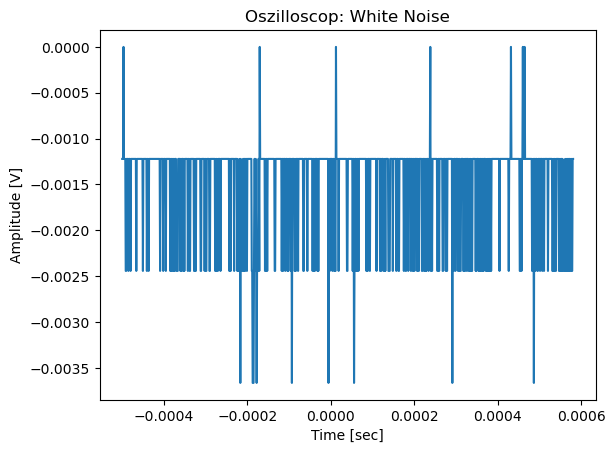

Detector noise = 4.779648947399712e-10 +/- 9.920144088426416e-12 mW
Detector noise = -93.20604 +/- 0.0901376625083019 dBm


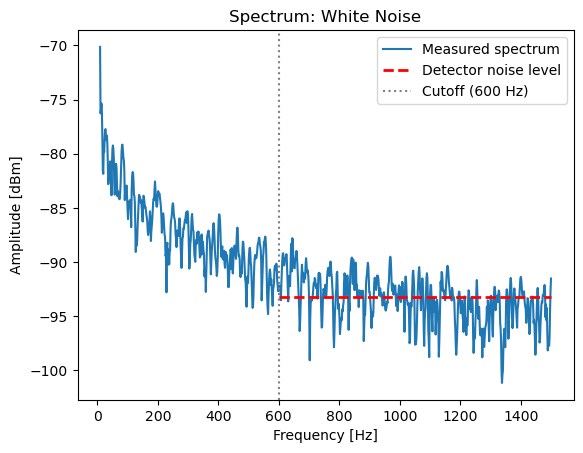

In [5]:
# CSV laden
data = pd.read_csv(
    "Messung_OS_teil3.csv",
    comment="%",
    header=None,
    names=["Time", "Amplitude"],
    skipinitialspace=True
)


A = data["Amplitude"]
T= data["Time"]

# Plot
plt.figure()
plt.plot(T, A)
plt.xlabel("Time [sec]")
plt.ylabel("Amplitude [V]")
plt.title("Oszilloscop: White Noise")
plt.savefig('Plots/OS_White_Noise.png')
plt.show()



# Daten laden
data = pd.read_csv(
    "Messung_SA_teil3.csv",
    comment="%",
    header=None,
    names=["Frequency_Hz", "Input1_dBm"],
    skipinitialspace=True
)

# Spalten extrahieren
f = data["Frequency_Hz"]
A = data["Input1_dBm"]

mask = f > 600

S_linear = 10**(A[mask] / 10)

S_det_linear = np.median(S_linear)
S_det_std = np.std(S_linear, ddof=1)
S_det_sem = S_det_std / np.sqrt(len(S_linear))

S_det_dBm = 10 * np.log10(S_det_linear)
S_det_dBm_unc = (10 / np.log(10)) * (S_det_sem / S_det_linear)

print("Detector noise =", S_det_linear, "+/-", S_det_sem, "mW")
print("Detector noise =", S_det_dBm, "+/-", S_det_dBm_unc, "dBm")


plt.figure()
plt.plot(f, A, label="Measured spectrum")
f_line = f[mask]
plt.plot(
    f_line,
    np.full_like(f_line, S_det_dBm),
    'r--',
    linewidth=2,
    label="Detector noise level"
)
plt.axvline(x=600, color='gray', linestyle=':', label="Cutoff (600 Hz)")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude [dBm]")
plt.title("Spectrum: White Noise")
plt.legend()
plt.savefig('Plots/SA_White_Noise.png', dpi=600)

plt.show()


# Schritt 4


=== Amplituden-Fit ===
A          = (4.92e+05 ± 1.38e+03)
omega0_amp = (5224.158 ± 0.028) rad/s
f0_amp     = (831.451 ± 0.004) Hz
Gamma_amp  = (22.757 ± 0.077) 1/s
Q_amp      = (229.57 ± 0.78)
C          = (0.000645 ± 0.00205)

=== Phasen-Fit ===
phi0        = (4.5770 ± 0.1005) rad
omega0_phase= (5223.207 ± 0.107) rad/s
f0_phase    = (831.299 ± 0.017) Hz
Gamma_phase = (22.488 ± 0.227) 1/s
Q_phase     = (232.27 ± 2.34)
a          = (-1.460e-04 ± 1.928e-05) s

Vergleich:
f0_amp      = (831.451 ± 0.004) Hz
f0_phase    = (831.299 ± 0.017) Hz
Gamma_amp   = (22.757 ± 0.077) 1/s
Gamma_phase = (22.488 ± 0.227) 1/s


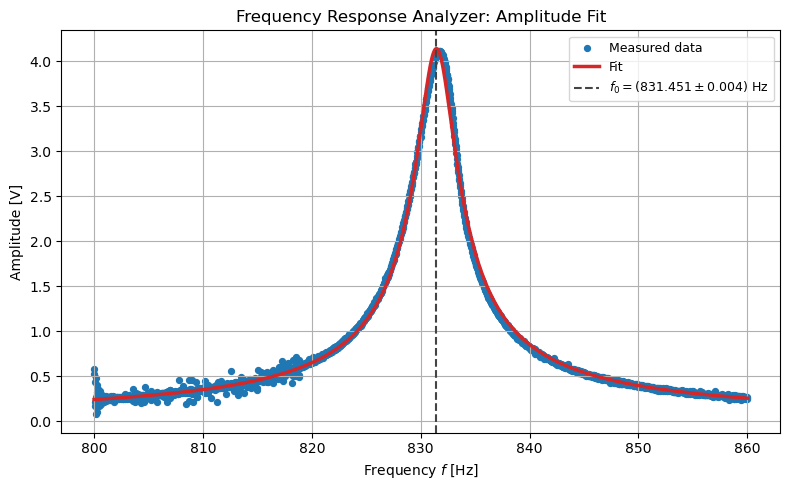

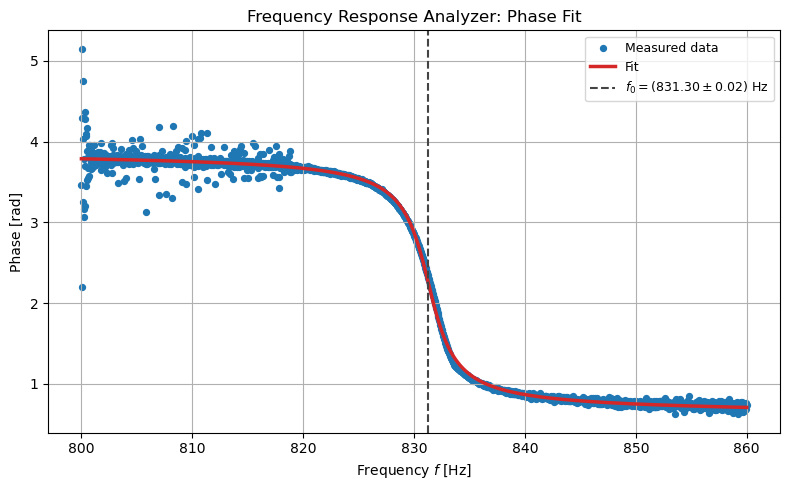

In [6]:
# Passe den Dateinamen an
filename = "Messung_FA_teil4.csv"

data = pd.read_csv(
    filename,
    comment="%",
    header=None,
    names=["Frequency_Hz", "Magnitude_dB", "Phase_deg"],
    skipinitialspace=True
)

f = data["Frequency_Hz"].to_numpy()
omega = 2 * np.pi * f

# FRA gibt Magnitude in dB aus.
# Für den Fit der Amplitude brauchen wir eine lineare Amplitude:
X  = 10**(data["Magnitude_dB"].to_numpy() / 20)

# Phase ist laut CSV in Grad:
phi_deg = data["Phase_deg"]
phi_unwrapped= (phi_deg*np.pi/180)%(2*np.pi)


# ============================================================
#FIT-FUNKTIONEN
# ============================================================

def amplitude_model(omega, A, omega0, Gamma, B):
    return A / np.sqrt((omega0**2 - omega**2)**2 + omega**2 * Gamma**2) + B

def phase_model(omega, omega0, Gamma, phi0,c):
    return -np.arctan2(omega * Gamma, omega0**2 - omega**2) + phi0 + omega*c


# ============================================================
# 3. STARTWERTE
# ============================================================

# Resonanzfrequenz grob aus Maximum der Amplitude
f0_guess = f[np.argmax(X)]
omega0_guess = 2 * np.pi * f0_guess

Gamma_guess = omega0_guess / 50   # grobe Annahme: Q ungefähr 50
A_guess = (np.max(X) - np.min(X)) * omega0_guess * Gamma_guess
B_guess = np.min(X)

p0_amp = [A_guess, omega0_guess, Gamma_guess, B_guess]
p0_phase = [2*np.pi*830, 4, np.pi, -0.001]


# ============================================================
# 4. AMPLITUDEN-FIT
# ============================================================

popt_amp, pcov_amp = curve_fit(
    amplitude_model,
    omega,
    X,
    p0=p0_amp,
    maxfev=10000
)

A_fit, omega0_fit_amp, Gamma_fit_amp, B_fit = popt_amp

f0_fit_amp = omega0_fit_amp / (2 * np.pi)
Q_fit_amp = omega0_fit_amp / Gamma_fit_amp


# ============================================================
# 5. PHASEN-FIT
# ============================================================


popt_phase, pcov_phase = curve_fit(
    phase_model,
    omega,
    phi_unwrapped ,
    p0=p0_phase,
    maxfev=10000
)

omega0_fit_phase, Gamma_fit_phase, phi0_fit, c_fit= popt_phase

f0_fit_phase = omega0_fit_phase / (2 * np.pi)
Q_fit_phase = omega0_fit_phase / Gamma_fit_phase


# ============================================================
# 6. RESULTATE AUSGEBEN
# ============================================================

# Fehler (Standardabweichungen) aus der Kovarianzmatrix:
A_err, omega0_err, Gamma_err, B_err = np.sqrt(np.diag(pcov_amp))

f0_err_amp = omega0_err / (2 * np.pi)

# Fehlerfortpflanzung für Q = omega0 / Gamma
Q_err_amp = Q_fit_amp * np.sqrt(
    (omega0_err / omega0_fit_amp)**2 +
    (Gamma_err / Gamma_fit_amp)**2
)

print("\n=== Amplituden-Fit ===")
print(f"A          = ({A_fit:.3g} ± {A_err:.3g})")
print(f"omega0_amp = ({omega0_fit_amp:.3f} ± {omega0_err:.3f}) rad/s")
print(f"f0_amp     = ({f0_fit_amp:.3f} ± {f0_err_amp:.3f}) Hz")
print(f"Gamma_amp  = ({Gamma_fit_amp:.3f} ± {Gamma_err:.3f}) 1/s")
print(f"Q_amp      = ({Q_fit_amp:.2f} ± {Q_err_amp:.2f})")
print(f"C          = ({B_fit:.3g} ± {B_err:.3g})")

# Fehler aus Kovarianzmatrix
omega0_phase_err, Gamma_phase_err, phi0_err, c_err = np.sqrt(np.diag(pcov_phase))

f0_err_phase = omega0_phase_err / (2 * np.pi)

# Fehlerfortpflanzung für Q = omega0 / Gamma
Q_err_phase = Q_fit_phase * np.sqrt(
    (omega0_phase_err / omega0_fit_phase)**2 +
    (Gamma_phase_err / Gamma_fit_phase)**2
)

print("\n=== Phasen-Fit ===")
print(f"phi0        = ({phi0_fit:.4f} ± {phi0_err:.4f}) rad")
print(f"omega0_phase= ({omega0_fit_phase:.3f} ± {omega0_phase_err:.3f}) rad/s")
print(f"f0_phase    = ({f0_fit_phase:.3f} ± {f0_err_phase:.3f}) Hz")
print(f"Gamma_phase = ({Gamma_fit_phase:.3f} ± {Gamma_phase_err:.3f}) 1/s")
print(f"Q_phase     = ({Q_fit_phase:.2f} ± {Q_err_phase:.2f})")
print(f"a          = ({c_fit:.3e} ± {c_err:.3e}) s")

print("\nVergleich:")
print(f"f0_amp      = ({f0_fit_amp:.3f} ± {f0_err_amp:.3f}) Hz")
print(f"f0_phase    = ({f0_fit_phase:.3f} ± {f0_err_phase:.3f}) Hz")
print(f"Gamma_amp   = ({Gamma_fit_amp:.3f} ± {Gamma_err:.3f}) 1/s")
print(f"Gamma_phase = ({Gamma_fit_phase:.3f} ± {Gamma_phase_err:.3f}) 1/s")


# ============================================================
# 7. PLOTS
# ============================================================

omega_plot = np.linspace(np.min(omega), np.max(omega), 2000)
f_plot = omega_plot / (2 * np.pi)

X_fit_plot = amplitude_model(omega_plot, *popt_amp)
phi_fit_plot = phase_model(omega_plot, *popt_phase)

# ---------- Amplitude plot ----------
plt.figure(figsize=(8, 5))

plt.scatter(f, X,color="#1f77b4", s=18, label="Measured data")
plt.plot(f_plot, X_fit_plot, color="#d62728", linewidth=2.5,label="Fit")
plt.axvline(
    f0_fit_amp,
    color = "#444444",
    linestyle="--",
    label=rf"$f_0 = ({f0_fit_amp:.3f} \pm {f0_err_amp:.3f})$ Hz"
)

plt.xlabel("Frequency $f$ [Hz]")
plt.ylabel("Amplitude [V]")
plt.title("Frequency Response Analyzer: Amplitude Fit")
plt.grid()

legend = plt.legend(loc="upper right", fontsize=9, frameon=True)
plt.tight_layout()
plt.savefig("Plots/FRA_amplitude_fit.png", dpi=600)
plt.show()


# ---------- Phase plot ----------
plt.figure(figsize=(8, 5))

plt.scatter(f, phi_unwrapped,color="#1f77b4", s=18, label="Measured data")
plt.plot(f_plot, phi_fit_plot, color="#d62728",linewidth=2.5, label="Fit")
plt.axvline(
    f0_fit_phase,
    color = "#444444",
    linestyle="--",
    label=rf"$f_0 = ({f0_fit_phase:.2f} \pm {f0_err_phase:.2f})$ Hz"
)

plt.xlabel("Frequency $f$ [Hz]")
plt.ylabel("Phase [rad]")
plt.title("Frequency Response Analyzer: Phase Fit")
plt.grid()

legend = plt.legend(loc="upper right", fontsize=9, frameon=True)
plt.tight_layout()
plt.savefig("Plots/FRA_phase_fit.png", dpi=600)
plt.show()

# Schritt 5

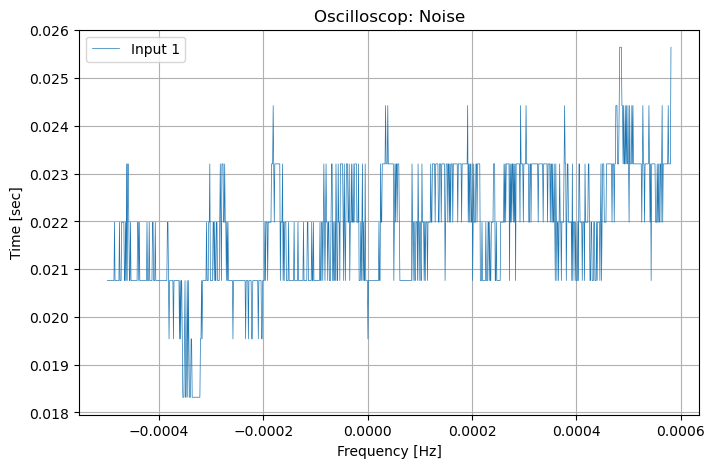

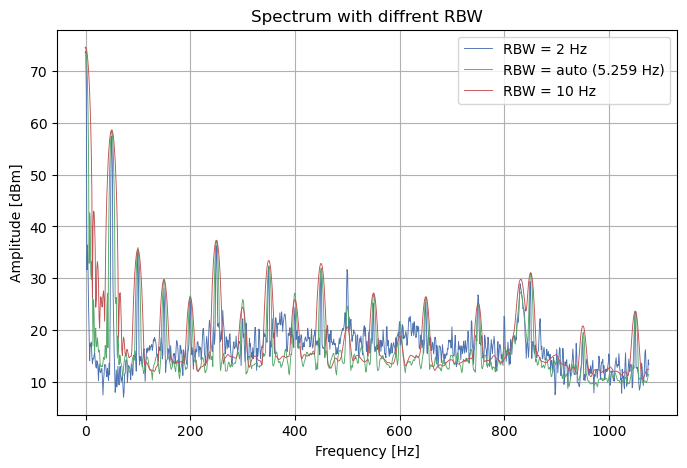

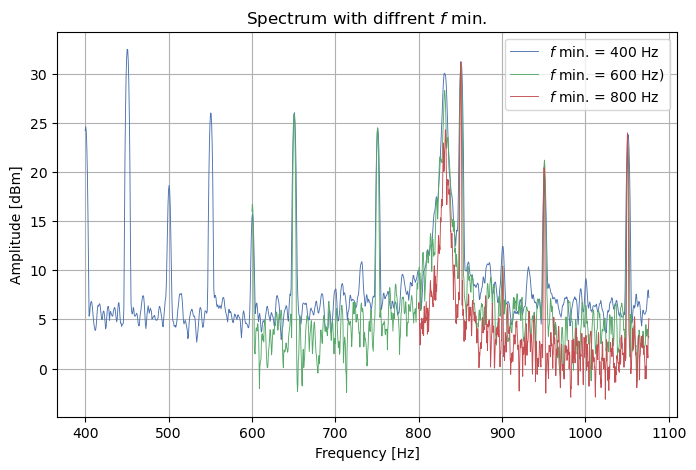

In [7]:



data = pd.read_csv(
    "Messung_OS_teil5.csv",
    comment="%",
    header=None,
    names=["Time", "Amplitude"],
    skipinitialspace=True
)

T_OS= data["Time"]
A_OS= data["Amplitude"]

plt.figure(figsize=(8, 5))
plt.plot(T_OS,A_OS,lw=0.5, label="Input 1")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Time [sec]")
plt.title("Oscilloscop: Noise")
plt.grid(True)
plt.legend()
plt.savefig("Plots/OS_rauschen.png", dpi=600)
plt.show()

data = pd.read_csv(
    "Messung_SA_teil5_RBW_2.csv",
    comment="%",
    header=None,
    names=["Frequency", "Amplitude"],
    skipinitialspace=True
)

F_RBW_2= data["Frequency"]
A_RBW_2= data["Amplitude"]- S_det_dBm

data = pd.read_csv(
    "Messung_SA_teil5_RBW_auto.csv",
    comment="%",
    header=None,
    names=["Frequency", "Amplitude"],
    skipinitialspace=True
)

F_RBW_auto= data["Frequency"]
A_RBW_auto= data["Amplitude"]- S_det_dBm


data = pd.read_csv(
    "Messung_SA_teil5_RBW_10.csv",
    comment="%",
    header=None,
    names=["Frequency", "Amplitude"],
    skipinitialspace=True
)

F_RBW_10= data["Frequency"]
A_RBW_10= data["Amplitude"]- S_det_dBm



plt.figure(figsize=(8, 5))
plt.plot(F_RBW_2,A_RBW_2,color="#4C72B0",lw=0.65, label="RBW = 2 Hz")
plt.plot(F_RBW_auto,A_RBW_auto,color="#55A868",lw=0.65, label="RBW = auto (5.259 Hz)")
plt.plot(F_RBW_10,A_RBW_10,color="#C44E52",lw=0.65, label="RBW = 10 Hz")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude [dBm]")
plt.title("Spectrum with diffrent RBW")
plt.grid(True)
plt.legend()
plt.savefig("Plots/diffrent_RBW.png", dpi=600)
plt.show()


data = pd.read_csv(
    "Messung_SA_teil5_fmin_400.csv",
    comment="%",
    header=None,
    names=["Frequency", "Amplitude"],
    skipinitialspace=True
)

F_fmin_400= data["Frequency"]
A_fmin_400= data["Amplitude"]- S_det_dBm


data = pd.read_csv(
    "Messung_SA_teil5_fmin_600.csv",
    comment="%",
    header=None,
    names=["Frequency", "Amplitude"],
    skipinitialspace=True
)
F_fmin_600= data["Frequency"]
A_fmin_600= data["Amplitude"]- S_det_dBm


data = pd.read_csv(
    "Messung_SA_teil5_fmin_800.csv",
    comment="%",
    header=None,
    names=["Frequency", "Amplitude"],
    skipinitialspace=True
)

F_fmin_800= data["Frequency"]
A_fmin_800 = data["Amplitude"] - S_det_dBm



plt.figure(figsize=(8, 5))
plt.plot(F_fmin_400,A_fmin_400,color = "#4C72B0", lw=0.65, label="$f$ min. = 400 Hz")
plt.plot(F_fmin_600,A_fmin_600,color = "#55A868",lw=0.65, label="$f$ min. = 600 Hz)")
plt.plot(F_fmin_800,A_fmin_800,color = "#C44E52",lw=0.65, label="$f$ min. = 800 Hz")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude [dBm]")
plt.title("Spectrum with diffrent $f$ min.")
plt.grid(True)
plt.legend()
plt.savefig("Plots/diffrent_fmin.png", dpi=600)
plt.show()

# Schritt 6

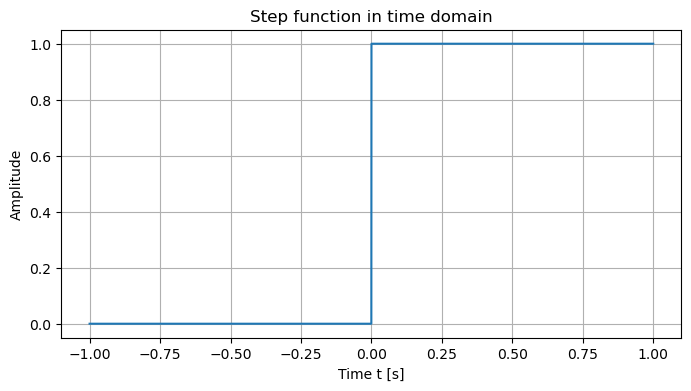

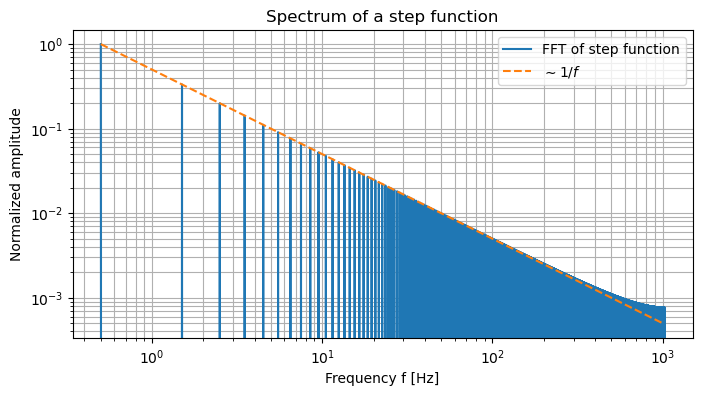

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameter
# -----------------------------
N = 4096              # Anzahl Punkte
T = 2.0               # gesamte Messzeit in Sekunden
dt = T / N            # Zeitauflösung

t = np.linspace(-T/2, T/2, N, endpoint=False)

# -----------------------------
# Stufenfunktion
# -----------------------------
step = np.heaviside(t, 1)

# -----------------------------
# Fourier-Transformation
# -----------------------------
fft_step = np.fft.fft(step)
freq = np.fft.fftfreq(N, d=dt)

# Nur positive Frequenzen
mask = freq > 0
freq_pos = freq[mask]
amp_pos = np.abs(fft_step[mask])

# Normierung für schöneren Plot
amp_pos = amp_pos / np.max(amp_pos)

# -----------------------------
# Plot 1: Zeitbereich
# -----------------------------
plt.figure(figsize=(8, 4))
plt.plot(t, step)
plt.xlabel("Time t [s]")
plt.ylabel("Amplitude")
plt.title("Step function in time domain")
plt.grid(True)
plt.savefig('Plots/Stepfunction_OS.png')
plt.show()

# -----------------------------
# Plot 2: Frequenzbereich
# -----------------------------
plt.figure(figsize=(8, 4))
plt.loglog(freq_pos, amp_pos, label="FFT of step function")

# Vergleichslinie ~ 1/f
comparison = 1 / freq_pos
comparison = comparison / np.max(comparison)

plt.loglog(freq_pos, comparison, "--", label=r"$\sim 1/f$")

plt.xlabel("Frequency f [Hz]")
plt.ylabel("Normalized amplitude")
plt.title("Spectrum of a step function")
plt.grid(True, which="both")
plt.legend()
plt.savefig('Plots/Stepfunction_spectrum.png')
plt.show()

# Teil 7

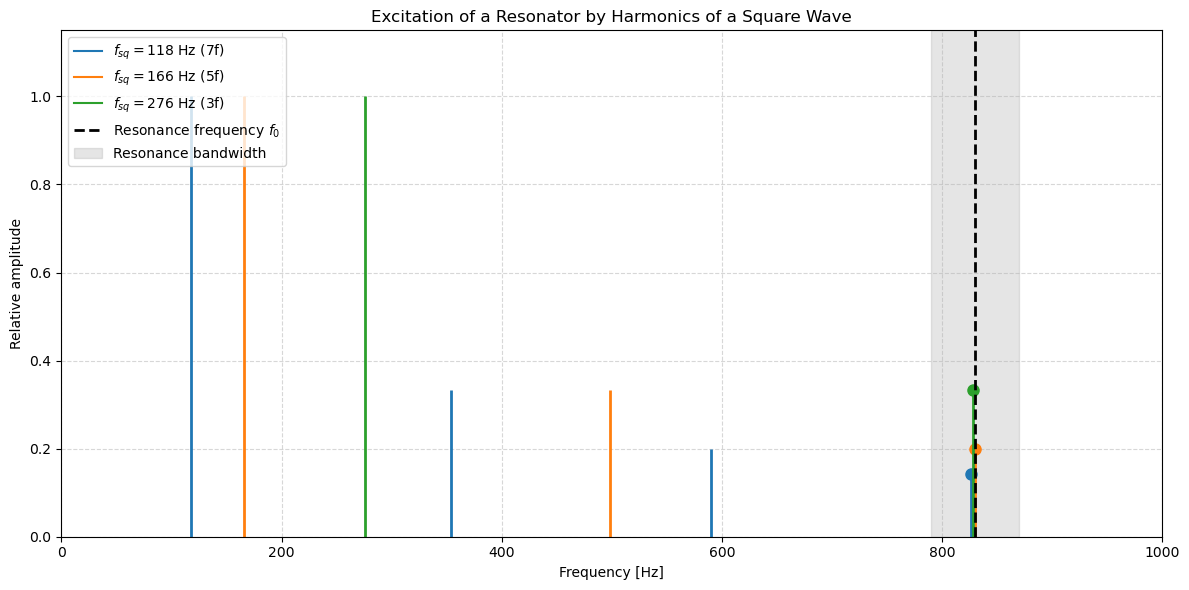

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Settings
# -----------------------------
f0 = 830
bandwidth = 80
f_squares = [118, 166, 276]

n_harmonics = 21
colors = ["tab:blue", "tab:orange", "tab:green"]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))

for f_square, color in zip(f_squares, colors):
    n = np.arange(1, n_harmonics + 1, 2)
    frequencies = n * f_square
    amplitudes = 1 / n

    
    plt.vlines(
        frequencies,
        0,
        amplitudes,
        color=color,
        linewidth=2
    )

    
    hits = np.abs(frequencies - f0) <= bandwidth / 2

    
    hit_labels = [f"{harmonic}f" for harmonic in n[hits]]

    
    plt.plot(
        frequencies[hits],
        amplitudes[hits],
        "o",
        color=color,
        markersize=8
    )

   
    if hit_labels:
        label_text = f"$f_{{sq}} = {f_square}$ Hz ({', '.join(hit_labels)})"
    else:
        label_text = f"$f_{{sq}} = {f_square}$ Hz"

    plt.plot([], [], color=color, label=label_text)


plt.axvline(
    f0,
    linestyle="--",
    linewidth=2,
    color="black",
    label=r"Resonance frequency $f_0$"
)

plt.axvspan(
    f0 - bandwidth / 2,
    f0 + bandwidth / 2,
    color="gray",
    alpha=0.2,
    label="Resonance bandwidth"
)


plt.title("Excitation of a Resonator by Harmonics of a Square Wave")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Relative amplitude")
plt.ylim(0, 1.15)
plt.xlim(0, 1000)
plt.grid(True, linestyle="--", alpha=0.5)

plt.legend()
plt.tight_layout()
plt.savefig('Plots/Harmonics_of_Squarewave.png')
plt.show()

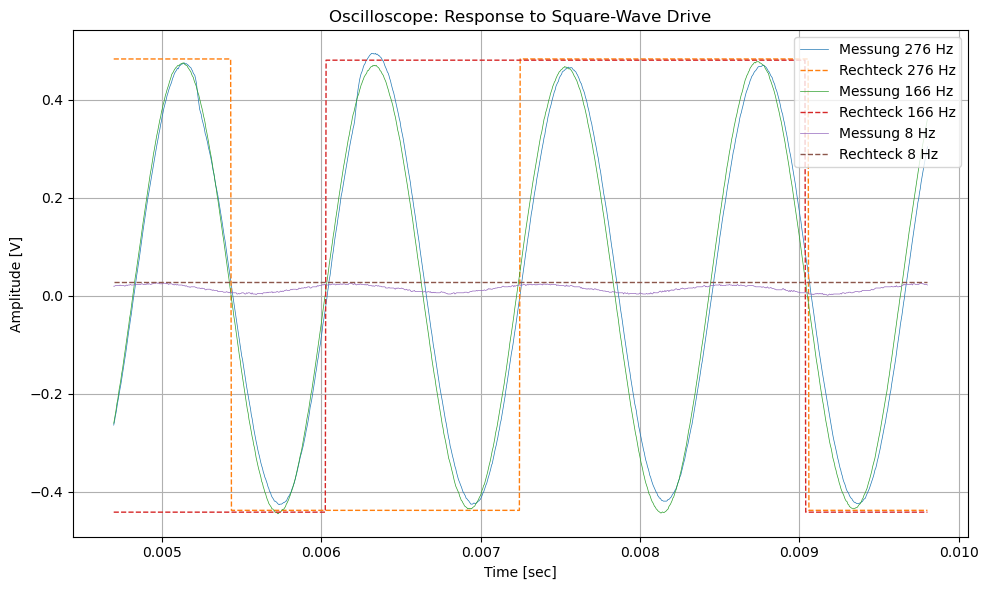

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import square

def load_os(filename):
    data = pd.read_csv(
        filename,
        comment="%",
        header=None,
        names=["Time", "Amplitude"],
        skipinitialspace=True
    )
    return data["Time"].to_numpy(), data["Amplitude"].to_numpy()

# Daten laden
T_OS_276, A_OS_276 = load_os("Messung_OS_teil7_276.csv")
T_OS_166, A_OS_166 = load_os("Messung_OS_teil7_166.csv")
T_OS_8,   A_OS_8   = load_os("Messung_OS_teil7.csv")

# Frequenzen der Rechtecksignale
f_276 = 276
f_166 = 166
f_8   = 8

def square_like_measurement(T, A, f):
    """
    Erzeugt ein Rechtecksignal mit gleicher Amplitude und gleichem Offset
    wie die Messung.
    """
    offset = np.mean(A)
    amp = (np.max(A) - np.min(A)) / 2
    return offset + amp * square(2 * np.pi * f * T)

# Rechtecksignale erzeugen
SQ_276 = square_like_measurement(T_OS_276, A_OS_276, f_276)
SQ_166 = square_like_measurement(T_OS_166, A_OS_166, f_166)
SQ_8   = square_like_measurement(T_OS_8,   A_OS_8,   f_8)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(T_OS_276, A_OS_276, lw=0.5, label="Messung 276 Hz")
plt.plot(T_OS_276, SQ_276, lw=1.0, linestyle="--", label="Rechteck 276 Hz")

plt.plot(T_OS_166, A_OS_166, lw=0.5, label="Messung 166 Hz")
plt.plot(T_OS_166, SQ_166, lw=1.0, linestyle="--", label="Rechteck 166 Hz")

plt.plot(T_OS_8, A_OS_8, lw=0.5, label="Messung 8 Hz")
plt.plot(T_OS_8, SQ_8, lw=1.0, linestyle="--", label="Rechteck 8 Hz")

plt.xlabel("Time [sec]")
plt.ylabel("Amplitude [V]")
plt.title("Oscilloscope: Response to Square-Wave Drive")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



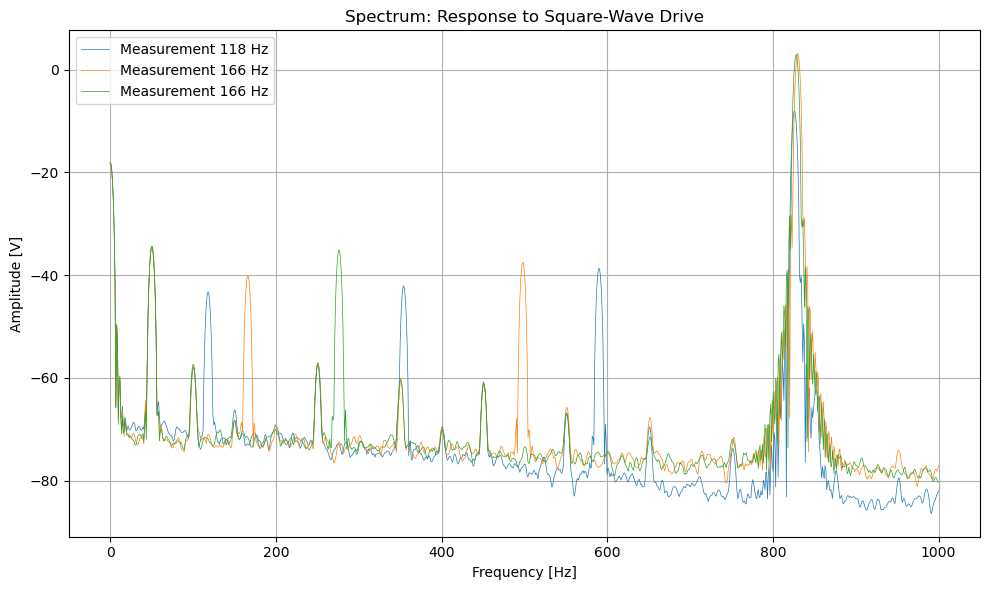

In [11]:
def load_os(filename):
    data = pd.read_csv(
        filename,
        comment="%",
        header=None,
        names=["Frequency", "Amplitude"],
        skipinitialspace=True
    )
    return data["Frequency"].to_numpy(), data["Amplitude"].to_numpy()

# Daten laden
F_SA_118, A_SA_118 = load_os("Messung_SA_teil7_118.csv") 
F_SA_166, A_SA_166 = load_os("Messung_SA_teil7_166.csv")
F_SA_276, A_SA_276   = load_os("Messung_SA_teil7_276.csv")


# Plot
plt.figure(figsize=(10, 6))

plt.plot(F_SA_118, A_SA_118, lw=0.5, label="Measurement 118 Hz")

plt.plot(F_SA_166, A_SA_166, lw=0.5, label="Measurement 166 Hz")

plt.plot(F_SA_276, A_SA_276, lw=0.5, label="Measurement 166 Hz")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude [V]")
plt.title("Spectrum: Response to Square-Wave Drive")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Plots/OS_different_freq_square.png", dpi=600)
plt.show()

# Schritt 8

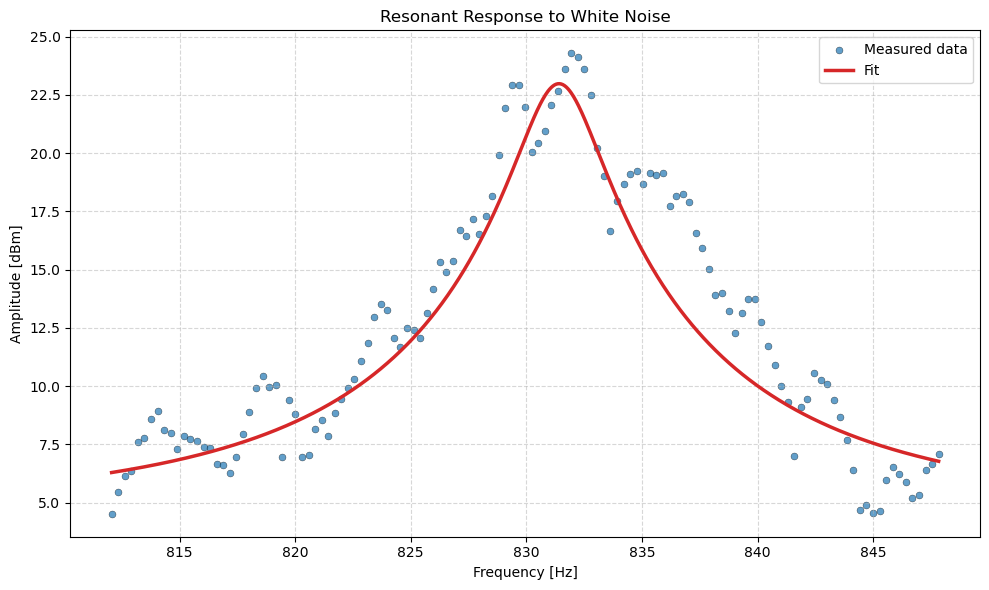

Fit Results:
f0 = 831.412 +/- 0.107 Hz
gamma = 21.342 +/- 1.223 rad/s

Abgeleitete Größen:
Resonanzbreite Δf = 3.397 ± 0.195 Hz
Q-Faktor          = 244.770 ± 14.023


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------------
# Helper functions
# -----------------------------
def dBm_to_linear(dBm):
    return 10**(dBm / 10)

def linear_to_dBm(P):
    return 10 * np.log10(P)

# -----------------------------
# 1. Model Function: PSD in linear units
# -----------------------------
def model_psd(f, f0, gamma, A, S_det):
    omega = 2 * np.pi * f
    omega0 = 2 * np.pi * f0

    psd = A / ((omega0**2 - omega**2)**2 + (omega * gamma)**2) + S_det
    return psd

# -----------------------------
# 2. Data Selection
# -----------------------------
mask = (F_fmin_800 >= 812) & (F_fmin_800 <= 848)

f_data = F_fmin_800[mask]
y_data_dBm = A_fmin_800[mask]

y_data_linear = dBm_to_linear(y_data_dBm)

S_det_linear = np.median(dBm_to_linear(A_fmin_800[:20]))

y_err_dBm = np.ones_like(y_data_dBm) * np.std(A_fmin_800[:20])

y_err_linear = y_data_linear * np.log(10) / 10 * y_err_dBm

y_err_linear = np.maximum(y_err_linear, np.min(y_data_linear) * 0.01)

# -----------------------------
# 3. Fitting
# -----------------------------
f0_guess = 831.5
gamma_guess = 22.5
A_guess = np.max(y_data_linear) * ((2*np.pi*f0_guess * gamma_guess)**2)

p0 = [f0_guess, gamma_guess, A_guess]
bounds = ([800, 0, 0], [860, np.inf, np.inf])

params, covariance = curve_fit(
    lambda f, f0, gamma, A: model_psd(f, f0, gamma, A, S_det_linear),
    f_data,
    y_data_linear,
    p0=p0,
    sigma=y_err_linear,
    absolute_sigma=True,
    bounds=bounds,
    maxfev=20000
)

# -----------------------------
# 4. Plotting in dBm again
# -----------------------------
f_fit_line = np.linspace(min(f_data), max(f_data), 1000)

y_fit_linear = model_psd(f_fit_line, *params, S_det_linear)
y_fit_dBm = linear_to_dBm(y_fit_linear)

plt.figure(figsize=(10, 6))

plt.scatter(f_data, y_data_dBm, s=25, alpha=0.7, edgecolors='black', linewidths=0.3, label="Measured data")
plt.plot(f_fit_line, y_fit_dBm, color="#d62728", linewidth=2.5, label="Fit")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude [dBm]")
plt.title("Resonant Response to White Noise")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
#plt.savefig("Plots/Fit_White_noise.png")
plt.show()

# -----------------------------
# 5. Results
# -----------------------------
f0_fit, gamma_fit, A_fit = params
f0_err, gamma_err, A_err = np.sqrt(np.diag(covariance))

print(f"Fit Results:")
print(f"f0 = {f0_fit:.3f} +/- {f0_err:.3f} Hz")
print(f"gamma = {gamma_fit:.3f} +/- {gamma_err:.3f} rad/s")

delta_f = gamma_fit / (2 * np.pi)
delta_f_err = gamma_err / (2 * np.pi)

Q = f0_fit / delta_f
Q_err = Q * np.sqrt((f0_err / f0_fit)**2 + (delta_f_err / delta_f)**2)

print("\nAbgeleitete Größen:")
print(f"Resonanzbreite Δf = {delta_f:.3f} ± {delta_f_err:.3f} Hz")
print(f"Q-Faktor          = {Q:.3f} ± {Q_err:.3f}")

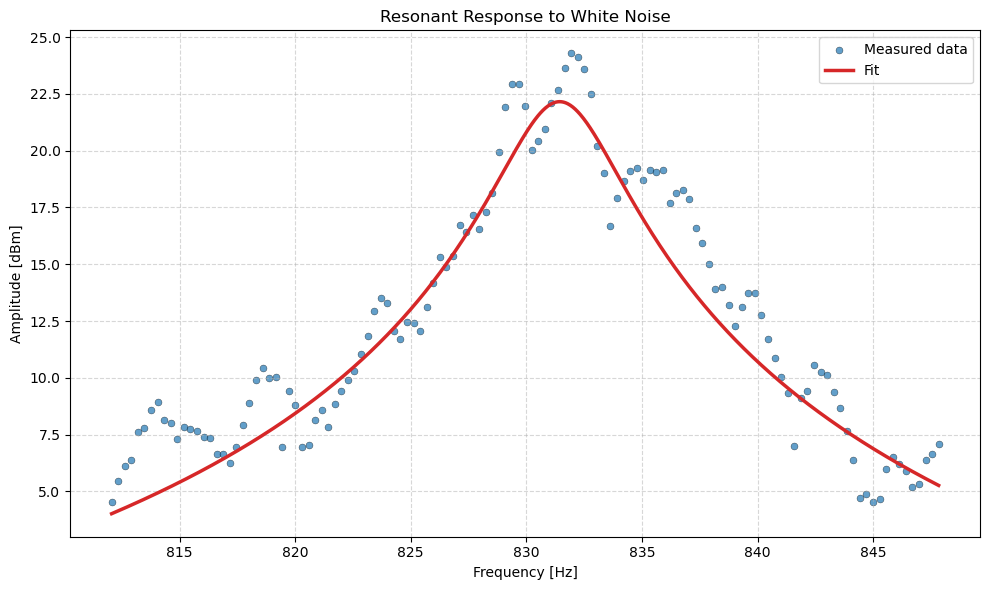

Fit Results:
f0 = 831.445 +/- 0.105 Hz
gamma = 30.046 +/- 1.974 rad/s
A = 4.050e+12 +/- 2.754e+11
S_det = 1.000e-07 +/- 3.672e-01
S_det = -70.000 +/- 15947181.197 dBm

Abgeleitete Größen:
Resonanzbreite Δf = 4.782 ± 0.314 Hz
Q-Faktor          = 173.871 ± 11.425


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------------
# Helper functions
# -----------------------------
def dBm_to_linear(dBm):
    return 10**(dBm / 10)

def linear_to_dBm(P):
    return 10 * np.log10(P)

# -----------------------------
# 1. Model Function: PSD in linear units
# -----------------------------
def model_psd(f, f0, gamma, A, S_det):
    omega = 2 * np.pi * f
    omega0 = 2 * np.pi * f0

    psd = A / ((omega0**2 - omega**2)**2 + (omega * gamma)**2) + S_det
    return psd

# -----------------------------
# 2. Data Selection
# -----------------------------
mask = (F_fmin_800 >= 812) & (F_fmin_800 <= 848)

f_data = F_fmin_800[mask]
y_data_dBm = A_fmin_800[mask]

y_data_linear = dBm_to_linear(y_data_dBm)

S_det_guess = dBm_to_linear(S_det_dBm)
#np.median(dBm_to_linear(A_fmin_800[:20]))

y_err_dBm = np.ones_like(y_data_dBm) * np.std(A_fmin_800[:20])
y_err_linear = y_data_linear * np.log(10) / 10 * y_err_dBm
y_err_linear = np.maximum(y_err_linear, np.min(y_data_linear) * 0.01)

# -----------------------------
# 3. Fitting
# -----------------------------
f0_guess = 831.5
gamma_guess = 22.5
A_guess = np.max(y_data_linear) * ((2*np.pi*f0_guess * gamma_guess)**2)

p0 = [f0_guess, gamma_guess, A_guess, S_det_guess]
bounds = ([800, 0, 0, dBm_to_linear(-110)], [860, np.inf, np.inf, dBm_to_linear(-70)])  

params, covariance = curve_fit(
    model_psd,
    f_data,
    y_data_linear,
    p0=p0,
    sigma=y_err_linear,
    absolute_sigma=True,
    bounds=bounds,
    maxfev=20000
)

# -----------------------------
# 4. Results
# -----------------------------
f0_fit, gamma_fit, A_fit, S_det_fit = params
f0_err, gamma_err, A_err, S_det_err = np.sqrt(np.diag(covariance))

delta_f = gamma_fit / (2 * np.pi)
delta_f_err = gamma_err / (2 * np.pi)

Q = f0_fit / delta_f
Q_err = Q * np.sqrt((f0_err / f0_fit)**2 + (delta_f_err / delta_f)**2)

S_det_fit_dBm = linear_to_dBm(S_det_fit)
S_det_err_dBm = 10 / np.log(10) * S_det_err / S_det_fit

# -----------------------------
# 5. Plotting in dBm again
# -----------------------------
f_fit_line = np.linspace(min(f_data), max(f_data), 1000)

y_fit_linear = model_psd(f_fit_line, *params)
y_fit_dBm = linear_to_dBm(y_fit_linear)

plt.figure(figsize=(10, 6))

plt.scatter(
    f_data,
    y_data_dBm,
    s=25,
    alpha=0.7,
    edgecolors='black',
    linewidths=0.3,
    label="Measured data"
)

plt.plot(
    f_fit_line,
    y_fit_dBm,
    color="#d62728",
    linewidth=2.5,
    label="Fit"
)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude [dBm]")
plt.title("Resonant Response to White Noise")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig("Plots/Fit_White_noise.png")
plt.show()

# -----------------------------
# 6. Print Results
# -----------------------------
print("Fit Results:")
print(f"f0 = {f0_fit:.3f} +/- {f0_err:.3f} Hz")
print(f"gamma = {gamma_fit:.3f} +/- {gamma_err:.3f} rad/s")
print(f"A = {A_fit:.3e} +/- {A_err:.3e}")
print(f"S_det = {S_det_fit:.3e} +/- {S_det_err:.3e}")
print(f"S_det = {S_det_fit_dBm:.3f} +/- {S_det_err_dBm:.3f} dBm")

print("\nAbgeleitete Größen:")
print(f"Resonanzbreite Δf = {delta_f:.3f} ± {delta_f_err:.3f} Hz")
print(f"Q-Faktor          = {Q:.3f} ± {Q_err:.3f}")

# Teil 9
### 50 Hz Störung

Im Spektrum tritt häufig ein Signal bei 50 Hz auf. Dieses stammt vom elektrischen Netz (Netzfrequenz in Europa) und koppelt über elektromagnetische Felder in das Experiment ein.

Zusätzlich können auch Harmonische bei 100 Hz, 150 Hz usw. auftreten.

Dieses Signal gehört nicht zur physikalischen Antwort des Resonators, sondern stellt ein Messartefakt dar und kann die Datenanalyse verfälschen.

Zur Entfernung kann der betroffene Frequenzbereich beim Fit ausgeschlossen werden. Alternativ können Filtermethoden oder eine verbesserte Abschirmung des Aufbaus verwendet werden.